## **Environment Setup**

In [2]:
!pip3 install requests

## **Data Ingestion**

In [3]:
import pandas as pd
import requests
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

url = "https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/04_Apply/Students_Alcohol_Consumption/student-mat.csv"
csv = "student-mat.csv"

res = requests.get(url, verify=False)

with open(csv, 'wb') as f:
    f.write(res.content)

df = pd.read_csv(csv)
display(df.head())

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## **Feature Selection and Data Split**

Dropping demographic columns to keep web application interface simple and avoid collecting unnecessary data by focusing purely on academic and behavioral factors on which Professors can act.

In [4]:
from sklearn.model_selection import train_test_split
print("Dataset Shape:", df.shape)

#target variable: 1 if final grade < 10, else 0
df['Risk'] = df['G3'].apply(lambda x: 1 if x < 10 else 0)
y = df['Risk']

grades = ['G1', 'G2', 'G3']
demos = [
    'school', 'sex', 'age', 'address', 'famsize',
     'reason', 'guardian', 'Medu','Fedu','Mjob','Fjob','Pstatus','schoolsup','famsup','paid','nursery','famrel'
]

drop = grades + demos + ['Risk']
x = df.drop(columns=drop)

x_tr, x_ts, y_tr, y_ts = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Train shape: {x_tr.shape}")
print(f"Test shape: {x_ts.shape}")
print(f"\nRemaining features:\n{x_tr.columns.tolist()}")
display(x_tr.head())

Dataset Shape: (395, 33)
Train shape: (316, 13)
Test shape: (79, 13)

Remaining features:
['traveltime', 'studytime', 'failures', 'activities', 'higher', 'internet', 'romantic', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


,traveltime,studytime,failures,activities,higher,internet,romantic,freetime,goout,Dalc,Walc,health,absences
181,1,2,0,yes,yes,yes,yes,2,3,1,2,3,2
194,2,1,0,no,yes,yes,no,3,3,1,1,3,0
173,1,2,3,yes,yes,yes,yes,3,5,1,1,3,0
63,1,3,0,yes,yes,yes,no,4,4,2,4,4,2
253,2,1,0,yes,yes,no,no,3,2,1,3,3,0


## **EDA: Missing Values and Outliers**

--- Missing Values ---
traveltime    0
studytime     0
failures      0
activities    0
higher        0
internet      0
romantic      0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
dtype: int64


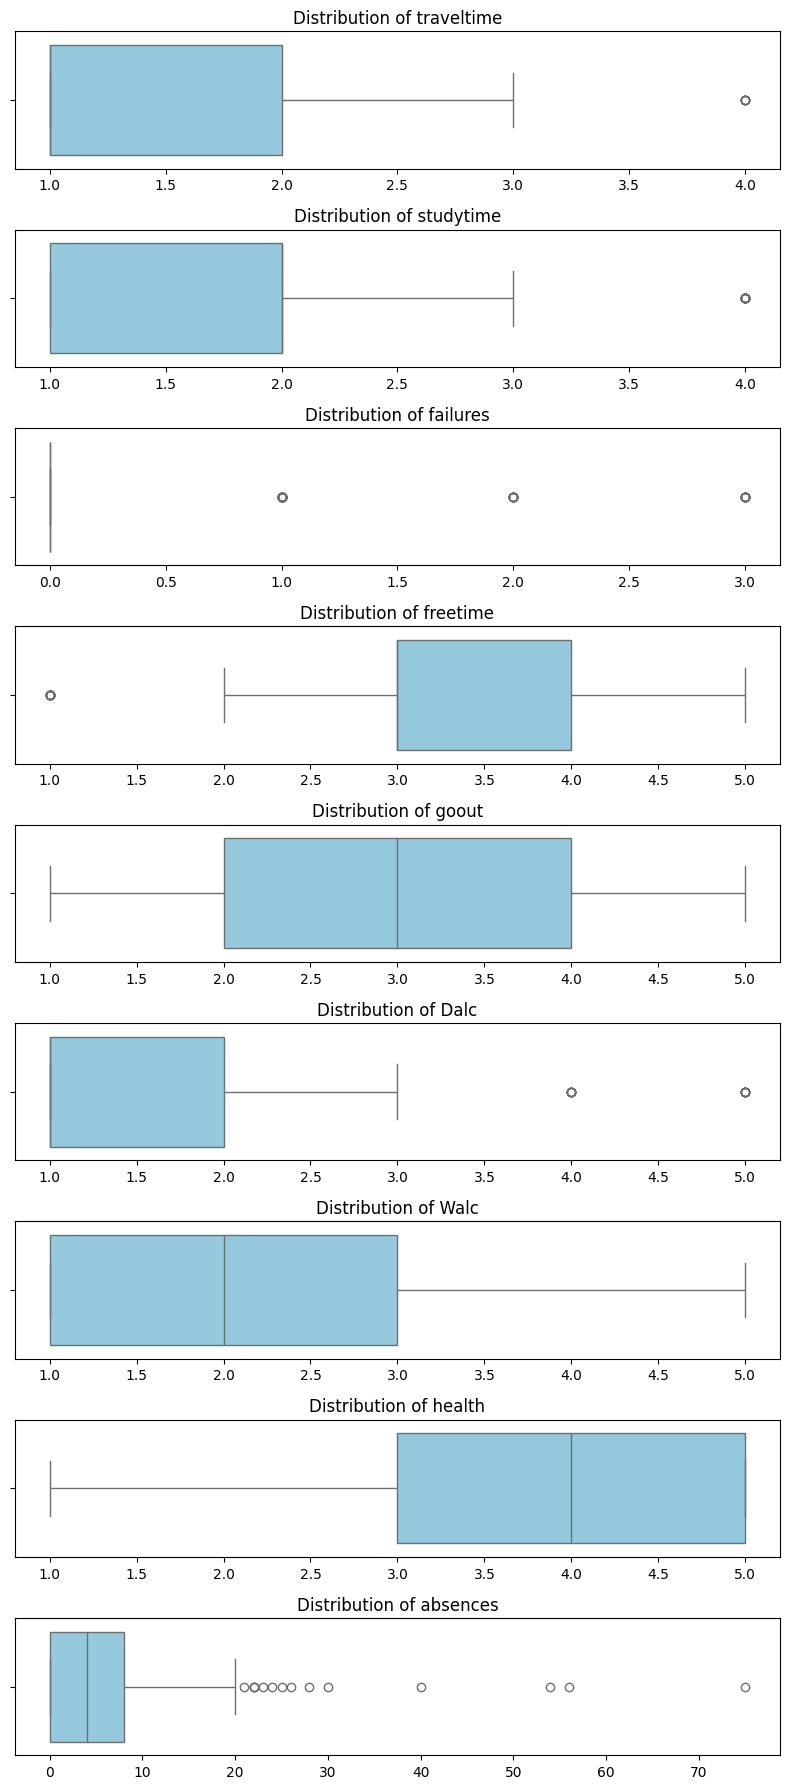

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Missing Values ---")
print(x_tr.isnull().sum())

# boxplots for numerical columns
num_cols = x_tr.select_dtypes(include=['int64', 'float64']).columns.tolist()
plt.figure(figsize=(8, 2 * len(num_cols)))
for i, col in enumerate(num_cols, 1):
  plt.subplot(len(num_cols), 1, i)
  sns.boxplot(data=x_tr, x=col, color='skyblue')
  plt.title(f'Distribution of {col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

## **Feature Pruning**

Based on initial training iterations and feature importance scores, 'traveltime','activities','activities_yes' yielded zero importance. Dropping these features to simplify input space and cleanup the feature list for the backend API.

In [6]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import joblib
import warnings

warnings.filterwarnings('ignore')
#Clean & Feature Engineer:
prune = ['traveltime', 'activities', 'activities_yes']
x_tr_c = x_tr.drop(columns=[c for c in prune if c in x_tr.columns])
x_ts_c = x_ts.drop(columns=[c for c in prune if c in x_ts.columns])

cat = x_tr_c.select_dtypes(include=['object', 'category']).columns
for c in cat:
    x_tr_c[c] = x_tr_c[c].map({'yes': 1, 'no': 0}).fillna(0).astype(int)
    x_ts_c[c] = x_ts_c[c].map({'yes': 1, 'no': 0}).fillna(0).astype(int)

renames = {'higher': 'higher_yes', 'internet': 'internet_yes', 'romantic': 'romantic_yes'}
x_tr_c = x_tr_c.rename(columns=renames)
x_ts_c = x_ts_c.rename(columns=renames)

feats = [
    "failures", "absences", "studytime", "freetime", "goout",
    "Dalc", "Walc", "health", "higher_yes", "internet_yes", "romantic_yes"]
x_tr_c = x_tr_c[feats]
x_ts_c = x_ts_c[feats]

print(f"Data cleaned. Ready with {x_tr_c.shape[1]} features.")

#Hyperparameter Grid Search:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

prm = {
    'n_estimators': [40, 50, 70],
    'max_depth': [2, 3],
    'learning_rate': [0.02, 0.05],
    'subsample': [0.6, 0.7, 0.8]
}

gs = GridSearchCV(xgb, prm, cv=3, scoring='roc_auc', n_jobs=None)
gs.fit(x_tr_c, y_tr)

print(f"Best params: {gs.best_params_}")
bst_mod = gs.best_estimator_

#Evaluation:
tr_p = bst_mod.predict_proba(x_tr_c)[:, 1]
ts_p = bst_mod.predict_proba(x_ts_c)[:, 1]

preds = (ts_p >= 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_ts, preds):.2%}")
print(f"ROC-AUC Score: {roc_auc_score(y_ts, ts_p):.4f}")

#Save Artifacts for Web Dev Backend:
joblib.dump(bst_mod, 'failsafe_xgboost_model.pkl')
joblib.dump(feats, 'model_features.pkl')

Data cleaned. Ready with 11 features.
Best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 40, 'subsample': 0.8}
Accuracy: 72.15%
ROC-AUC Score: 0.7172


['model_features.pkl']

## **Feature Importance Analysis**

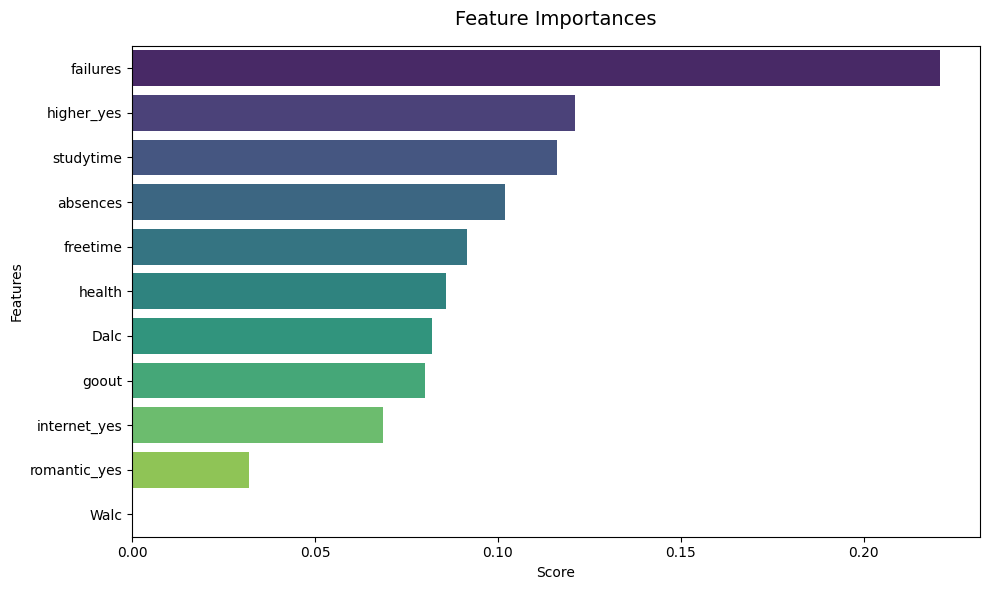

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

imp = bst_mod.feature_importances_

imp_df = pd.DataFrame({
    'Feature': feats,
    'Importance': imp
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=imp_df,
    x='Importance',
    y='Feature',
    palette='viridis',
    hue='Feature',
    legend=False
)

plt.title('Feature Importances', fontsize=14, pad=15)
plt.xlabel('Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## **Model Interpretation (SHAP Values)**

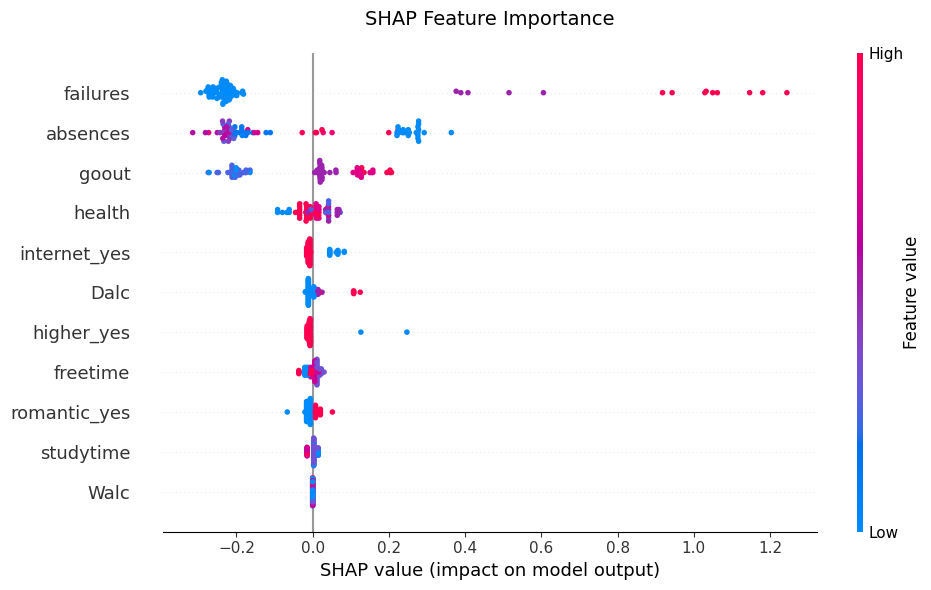

In [8]:
import shap
import matplotlib.pyplot as plt

expl = shap.TreeExplainer(bst_mod)
vals = expl.shap_values(x_ts_c)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    vals,
    x_ts_c,
    max_display=11,
    plot_size=None,
    show=False
)
plt.title('SHAP Feature Importance', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## **Exporting Production Assets**

In [9]:
import shap
from google.colab import files

expl = shap.TreeExplainer(bst_mod)
bndl = {
    "model": bst_mod,
    "explainer": expl,
    "feature_names": feats
}
joblib.dump(bndl, 'failsafe_production_engine.pkl')
files.download('failsafe_production_engine.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**Model Metrics:**

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

preds = (bst_mod.predict_proba(x_ts_c)[:, 1] >= 0.5).astype(int)

acc = accuracy_score(y_ts, preds)
prec = precision_score(y_ts, preds)
rec = recall_score(y_ts, preds)
f1 = f1_score(y_ts, preds)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall (Sensitivity): {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.7215
Precision: 0.8571
Recall (Sensitivity): 0.2222
F1 Score: 0.3529
